In [131]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error , mean_squared_error
from prophet import Prophet

In [132]:
# dataset
df = pd.read_csv("seattle_weather.csv")

In [133]:
# Fisrt 5 rows
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [134]:
# last 5 rows
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


In [135]:
# Shape of the dataset
print("Shape of the Dataset")
df.shape

Shape of the Dataset


(1461, 6)

In [136]:
# Statistical Summary
print("Descriptive Statistics of Numerical Column")
df.describe()

Descriptive Statistics of Numerical Column


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [137]:
# Datatypes
print("Datatypes of Each Column")
print(df.dtypes)

Datatypes of Each Column
date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object


In [138]:
# Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [139]:
# Null values count
missing_values = df.isnull().sum()
print("Missing Values for Each Column: ")
print(missing_values)

Missing Values for Each Column: 
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [140]:
#Duplicate Row Count
duplicates = df.duplicated().sum()
print("Duplicated Row Count :")
print(duplicates)

Duplicated Row Count :
0


In [141]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

In [142]:
df.head()

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


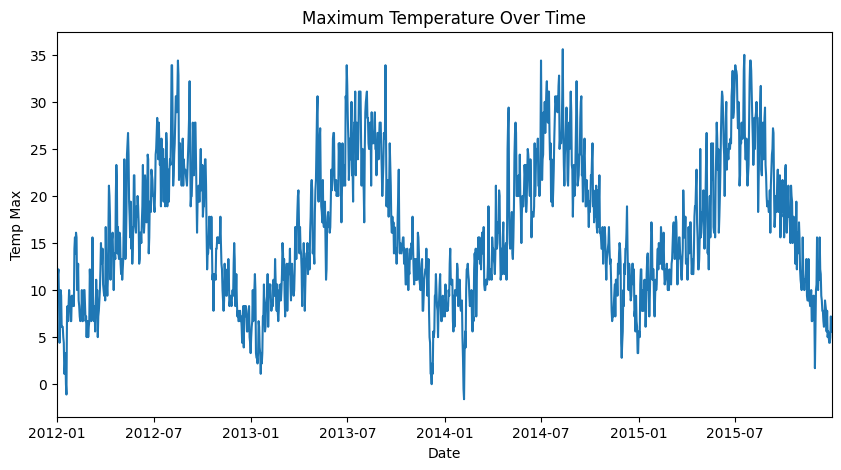

In [143]:
# Prophet Model for Maximum Temperature
tseries_tempmax = df['temp_max']

plt.figure(figsize=(10,5))
plt.plot(tseries_tempmax)
plt.title("Maximum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temp Max")
plt.xlim(df.index.min(), df.index.max())
plt.show()

In [144]:
# Train- Test_ split model for Maximum Temperature
prophet_df = df.reset_index()[['date', 'temp_max']]
prophet_df.columns = ['ds', 'y']

train_size = int(len(prophet_df) * 0.8)

train_max = prophet_df[:train_size]
test_max = prophet_df[train_size:]

In [145]:
# Model
model_max = Prophet()
model_max.fit(train_max)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [146]:
# Predictions
future = model_max.make_future_dataframe(periods=len(test_max))

forecast = model_max.predict(future)
forecast_test = forecast[['ds', 'yhat']].iloc[train_size:]

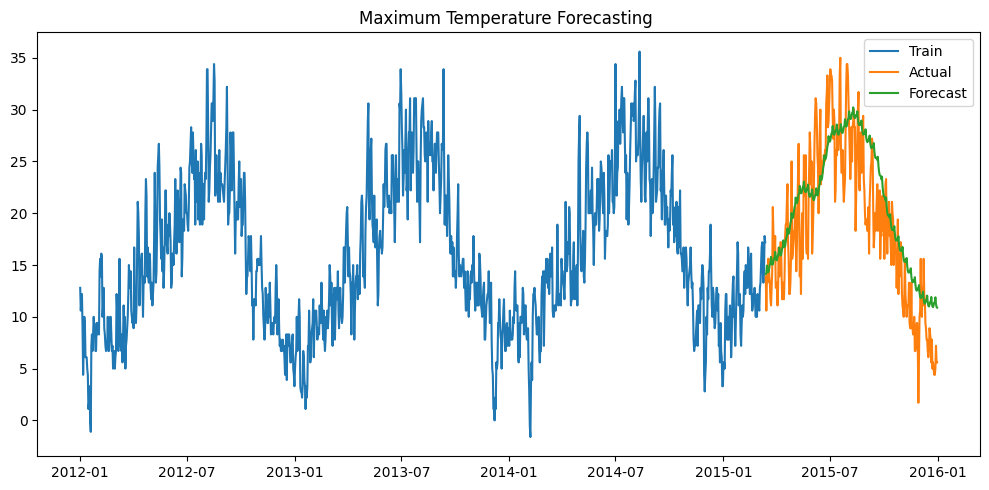

In [147]:
# visuliasation for predictions of Maximum Temperature
plt.figure(figsize=(10,5))
plt.plot(train_max['ds'], train_max['y'], label="Train")
plt.plot(test_max['ds'], test_max['y'], label="Actual")
plt.plot(forecast_test['ds'], forecast_test['yhat'], label="Forecast")
plt.legend()
plt.title("Maximum Temperature Forecasting ")
plt.tight_layout()
plt.show()

In [148]:
# Calculate Mean absolute error and mean square error
MAE = mean_absolute_error(test_max['y'], forecast_test['yhat'])
RMSE = np.sqrt(mean_squared_error(test_max['y'], forecast_test['yhat']))

print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 3.6243732615912156
RMSE: 4.359335066279575


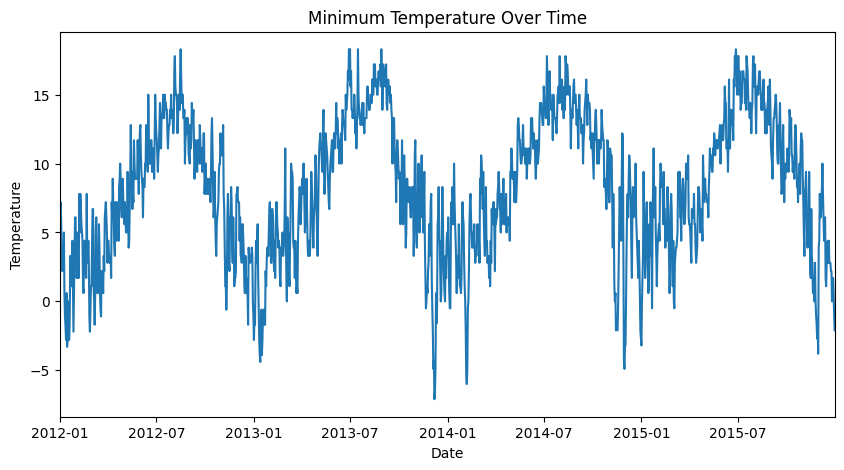

In [149]:
# Model for Minimum Temperature
tseries_tempmin = df['temp_min']

plt.figure(figsize=(10,5))
plt.plot(tseries_tempmin)
plt.title("Minimum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xlim(df.index.min(), df.index.max())
plt.show()

In [150]:
# Train- Test_split model for Minimum Temperature
prophet_df_min = df.reset_index()[['date', 'temp_min']]
prophet_df_min.columns = ['ds', 'y']

train_size = int(len(prophet_df_min) * 0.8)

train_min = prophet_df_min[:train_size]
test_min = prophet_df_min[train_size:]

# Model
model_min = Prophet()
model_min.fit(train_min)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [151]:
future_min = model_min.make_future_dataframe(periods=len(test_min))

forecast_min = model_min.predict(future_min)

forecast_test_min = forecast_min[['ds', 'yhat']].iloc[train_size:]

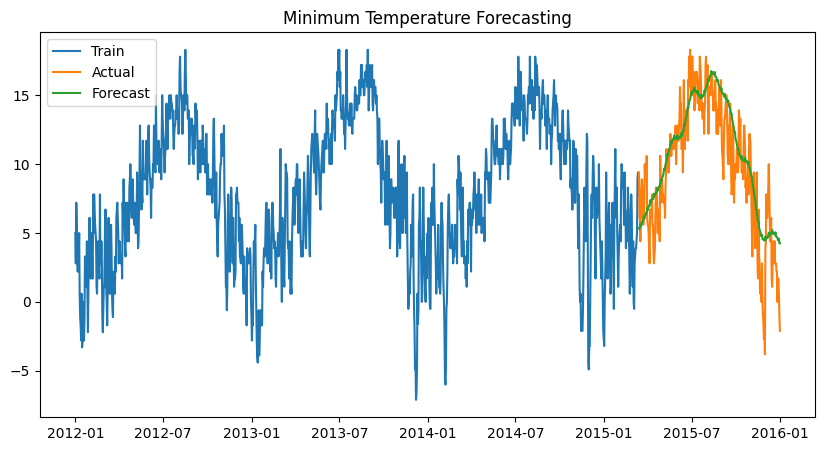

In [152]:
# visuliasation for predictions of Minimum Temperature
plt.figure(figsize=(10,5))
plt.plot(train_min['ds'], train_min['y'], label="Train")
plt.plot(test_min['ds'], test_min['y'], label="Actual")
plt.plot(forecast_test_min['ds'], forecast_test_min['yhat'], label="Forecast")
plt.legend()
plt.title("Minimum Temperature Forecasting")
plt.show()

In [153]:
# Calculate Mean absolute error and mean square error
MAE = mean_absolute_error(test_min['y'], forecast_test_min['yhat'])
RMSE = np.sqrt(mean_squared_error(test_min['y'], forecast_test_min['yhat']))

print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 1.9221487109415898
RMSE: 2.4569531915798213
